# Feature Engineering & Modelo de Recomendación de Productos

**Objetivo:** Predecir qué clientes adquirirán un nuevo producto bancario el siguiente mes.  
**Dataset:** TAD.csv — 2.4M registros mensuales de clientes (Ene 2018 – May 2019)  
**Modelo:** XGBoost con `scale_pos_weight` + lag features temporales  
**Splits:** Train (≤ Ene 2019) / Val (Feb–Mar 2019) / Test (Abr–May 2019)

## Flujo del notebook

```
Carga → EDA → Feature Engineering → Imputación → Optuna → XGBoost → Evaluación → Conclusiones
```

| Sección | Descripción |
|---------|-------------|
| 1. Configuración | Librerías, MLflow |
| 2. Carga de Datos | TAD.csv, estructura y exploración |
| 3. Feature Engineering | Lag features, delta, historial de compras |
| 4. Separación de Features | Train / Val / Test |
| 5. Pipeline | Encoders, imputación, XGBoost |
| 6. Entrenamiento | Optuna + modelo final |
| 7. Evaluación en Test | Métricas, confusion matrix, PR-AUC |
| 8. Feature Importance | Top 15 variables |
| 9. Análisis de Resultados | Lift, deciles, perfil comprador |
| 10. Conclusiones | Resumen ejecutivo y próximos pasos |


## 1. Configuración

In [ ]:
import os
import warnings
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import mlflow
import mlflow.sklearn

from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score,
)

warnings.filterwarnings('ignore')
logging.getLogger('mlflow').setLevel(logging.ERROR)
pd.set_option('display.max_columns', None)
sklearn.set_config(transform_output='pandas')


Configuración lista.


## 2. Carga de Datos

In [ ]:
df = pd.read_csv('TAD.csv', index_col=0)
df['pk_partition'] = df['pk_partition'].astype('datetime64[ns]')
df['entry_date']   = df['entry_date'].astype('datetime64[ns]')

print(f'Shape: {df.shape}')
df.head(3)

Shape: (2404633, 28)


,pk_partition,age,gender,salary,region_code,country_id,entry_channel,entry_date,segment,active_customer,seniority_months,credit_card,debit_card,em_account_p,em_account_pp,em_acount,emc_account,funds,loans,long_term_deposit,mortgage,payroll,payroll_account,pension_plan,securities,short_term_deposit,n_products_total,target
pk_cid,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1375586,2018-01-01,35,Male,87218.10,29.0,ES,KHL,2018-01-01,02 - PARTICULARES,1.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
1330978,2018-01-01,40,Male,155695.68,28.0,ES,KFC,2017-10-01,02 - PARTICULARES,1.0,3,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0
1330977,2018-01-01,21,Male,71172.39,15.0,ES,KFC,2017-10-01,03 - UNIVERSITARIO,1.0,3,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0


---
## 2.1 Análisis Exploratorio de Datos

### 2.1.1 Distribución y limpieza de Salary

Antes de modelar, analizamos la variable `salary`:  
- **~46%** de los registros tienen `salary` nulo → se imputarán en la sección 3.2  
- El salary es **constante por cliente** a lo largo del tiempo (no varía entre particiones)  
- Hay **7,817 clientes (6%)** con salary > 236k€ (outliers IQR) que se eliminan para no distorsionar la imputación

In [ ]:
Q1  = df['salary'].quantile(0.25)
Q3  = df['salary'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['salary'] < lower) | (df['salary'] > upper)]
print(f"Límite inferior: {lower:,.0f}")
print(f"Límite superior: {upper:,.0f}")
print(f"Outliers: {len(outliers):,} ({len(outliers)/len(df)*100:.1f}%)")


Límite inferior: -41,411
Límite superior: 238,877
Outliers: 109,470 (4.6%)


In [ ]:
# Un salary por cliente (tomar el primero no nulo, ya que no varía)
salary_cid = (
    df.dropna(subset=['salary'])
      .groupby('pk_cid')['salary']
      .first()
)

# Estadísticos
print("── Estadísticos de salary por pk_cid ────────────────")
print(f"Clientes con salary:     {len(salary_cid):>10,}")
print(f"Clientes sin salary:     {df.groupby('pk_cid')['salary'].first().isna().sum():>10,}")
print()
print(salary_cid.describe().apply(lambda x: f"{x:>12,.2f}"))
print(f"{'Skewness':.<25}{salary_cid.skew():>12.3f}")
print(f"{'Kurtosis':.<25}{salary_cid.kurt():>12.3f}")
print(f"{'P1':.<25}{salary_cid.quantile(0.01):>12,.2f}")
print(f"{'P5':.<25}{salary_cid.quantile(0.05):>12,.2f}")
print(f"{'P95':.<25}{salary_cid.quantile(0.95):>12,.2f}")
print(f"{'P99':.<25}{salary_cid.quantile(0.99):>12,.2f}")

# Outliers por IQR
Q1, Q3 = salary_cid.quantile(0.25), salary_cid.quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

n_out_low  = (salary_cid < lower).sum()
n_out_high = (salary_cid > upper).sum()
print(f"\n── Outliers IQR ──────────────────────────────────────")
print(f"Límite inferior (Q1-1.5·IQR): {lower:>12,.2f}  →  {n_out_low:,} clientes")
print(f"Límite superior (Q3+1.5·IQR): {upper:>12,.2f}  →  {n_out_high:,} clientes")


# Filtrar outliers de salary a nivel cliente (pk_cid es el índice)
Q1    = salary_cid.quantile(0.25)
Q3    = salary_cid.quantile(0.75)
IQR   = Q3 - Q1
upper = Q3 + 1.5 * IQR

cids_outliers = salary_cid[salary_cid > upper].index

df_clean = df[~df.index.isin(cids_outliers)].copy()

print(f"Filas originales:    {len(df):>10,}")
print(f"Clientes eliminados: {len(cids_outliers):>10,}")
print(f"Filas resultantes:   {len(df_clean):>10,}")


── Estadísticos de salary por pk_cid ────────────────
Clientes con salary:        129,013
Clientes sin salary:         68,680

count       129,013.00
mean        116,208.67
std         210,790.49
min           3,731.79
25%          63,288.66
50%          90,597.66
75%         132,670.32
max      28,894,395.51
Name: salary, dtype: object
Skewness.................      66.167
Kurtosis.................    6675.006
P1.......................   24,759.09
P5.......................   37,842.25
P95......................  255,186.41
P99......................  463,888.47

── Outliers IQR ──────────────────────────────────────
Límite inferior (Q1-1.5·IQR):   -40,783.83  →  0 clientes
Límite superior (Q3+1.5·IQR):   236,742.81  →  7,817 clientes
Filas originales:     2,404,633
Clientes eliminados:      7,817
Filas resultantes:    2,292,772


### 2.1.2 Comportamiento del Target

Analizamos la **tasa de compra** a lo largo del tiempo y distinguimos  
clientes de primera compra vs clientes que repiten.

> La clase positiva (compra = 1) supone el **6.43%** del dataset → desbalanceo 13:1

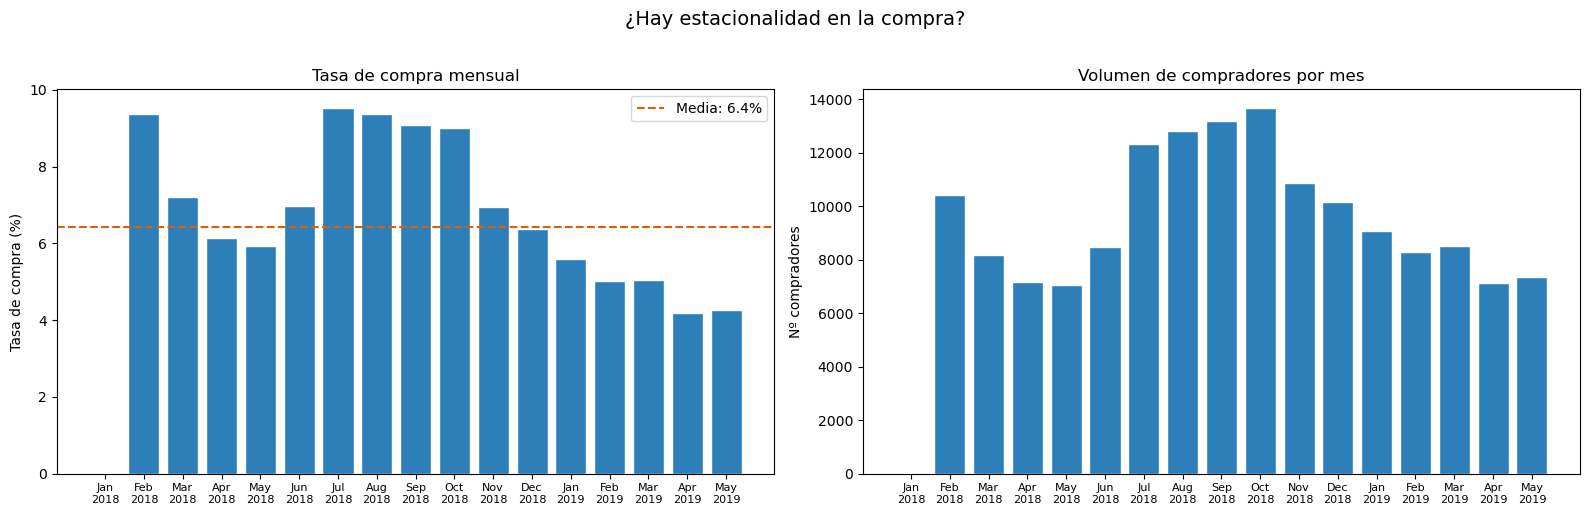

Tasa media de compra: 6.43%
Mes con mayor tasa:   July 2018 (9.54%)
Mes con menor tasa:   January 2018 (0.00%)

=== Tasa de compra: clientes nuevos vs recurrentes ===
                tasa_compra  n_registros
Primera compra         3.20      1464583
Recompra              11.46       940050

Lift de recompra: 3.6x


In [ ]:
# Evolución temporal de la tasa de compra
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

tasa_mensual = df.groupby('pk_partition')['target'].mean() * 100
axes[0].bar(range(len(tasa_mensual)), tasa_mensual.values, color='#2c7fb8', edgecolor='white')
axes[0].set_xticks(range(len(tasa_mensual)))
axes[0].set_xticklabels([d.strftime('%b\n%Y') for d in tasa_mensual.index], fontsize=8)
axes[0].set_ylabel('Tasa de compra (%)')
axes[0].set_title('Tasa de compra mensual')
axes[0].axhline(df['target'].mean() * 100, color='#d95f0e', linestyle='--', label=f'Media: {df["target"].mean()*100:.1f}%')
axes[0].legend()

compradores_mes = df.groupby('pk_partition')['target'].sum()
axes[1].bar(range(len(compradores_mes)), compradores_mes.values, color='#2c7fb8', edgecolor='white')
axes[1].set_xticks(range(len(compradores_mes)))
axes[1].set_xticklabels([d.strftime('%b\n%Y') for d in compradores_mes.index], fontsize=8)
axes[1].set_ylabel('Nº compradores')
axes[1].set_title('Volumen de compradores por mes')

plt.suptitle('¿Hay estacionalidad en la compra?', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'Tasa media de compra: {df["target"].mean()*100:.2f}%')
print(f'Mes con mayor tasa:   {tasa_mensual.idxmax().strftime("%B %Y")} ({tasa_mensual.max():.2f}%)')
print(f'Mes con menor tasa:   {tasa_mensual.idxmin().strftime("%B %Y")} ({tasa_mensual.min():.2f}%)')

# Primera compra vs recompra
df_sorted = df.sort_values(['pk_partition'])
df_sorted['compras_previas'] = df_sorted.groupby(df_sorted.index)['target'].cumsum().shift(1).fillna(0)
df_sorted['es_recompra'] = (df_sorted['compras_previas'] > 0).astype(int)

tasa_por_tipo = df_sorted.groupby('es_recompra')['target'].agg(['mean', 'count'])
tasa_por_tipo.columns = ['tasa_compra', 'n_registros']
tasa_por_tipo.index = ['Primera compra', 'Recompra']
tasa_por_tipo['tasa_compra'] = (tasa_por_tipo['tasa_compra'] * 100).round(2)

print('\n=== Tasa de compra: clientes nuevos vs recurrentes ===')
print(tasa_por_tipo.to_string())
print(f'\nLift de recompra: {tasa_por_tipo.loc["Recompra", "tasa_compra"] / tasa_por_tipo.loc["Primera compra", "tasa_compra"]:.1f}x')

df_sorted.drop(columns=['compras_previas', 'es_recompra'], inplace=True)

## 3. Feature Engineering

### 3.1 Lag Features

Creamos el historial de productos de cada cliente para los **2 meses anteriores**.  
Estos features resultaron ser los más predictivos del modelo (ver sección 7).

> **Nota:** Los lags se calculan sobre el dataset completo **antes del split** para evitar pérdida de información en los clientes del conjunto de validación y test.

In [ ]:
# ── Definición de productos ─────────────────────────────────────────────────
df = df.sort_values('pk_partition')

PRODUCT_COLS = [
    'credit_card', 'debit_card', 'em_account_p', 'em_account_pp',
    'em_acount', 'emc_account', 'funds', 'loans', 'long_term_deposit',
    'mortgage', 'payroll', 'payroll_account', 'pension_plan',
    'securities', 'short_term_deposit'
]

for lag in [1, 2]:
    for col in PRODUCT_COLS:
        df[f'{col}_lag{lag}'] = df.groupby(df.index)[col].shift(lag)

LAG_COLS = [f'{col}_lag{lag}' for lag in [1, 2] for col in PRODUCT_COLS]
print(f'Lag features creadas: {len(LAG_COLS)} — shape total: {df.shape}')

# ── Features adicionales de historial ────────────────────────────────────────
df['n_products_total_lag1'] = df.groupby(df.index)['n_products_total'].shift(1)
df['n_products_total_lag2'] = df.groupby(df.index)['n_products_total'].shift(2)
df['delta_products']        = df['n_products_total_lag1'] - df['n_products_total_lag2']

# Historial de compras
df['bought_last_month']    = df.groupby(df.index)['target'].shift(1)
df['bought_2months_ago']   = df.groupby(df.index)['target'].shift(2)
df['cumulative_purchases'] = df.groupby(df.index)['target'].cumsum().shift(1).fillna(0)

# Meses desde la última compra
df['buy_date']      = df['pk_partition'].where(df['target'] == 1)
df['last_buy_date'] = df.groupby(df.index)['buy_date'].shift(1).groupby(df.index).ffill()
df['months_since_purchase'] = (
    (df['pk_partition'] - df['last_buy_date']).dt.days / 30.44
).round(0)
df.drop(columns=['buy_date'], inplace=True)

print(f'Shape final con todas las features: {df.shape}')

Lag features creadas: 30 — shape total: (2404633, 58)
Shape final con todas las features: (2404633, 66)


### 3.2 Imputación de Salary

El 25% de los registros tiene `salary` nulo.  
Usamos `IterativeImputer` entrenado **solo en train** para estimar el salario a partir de edad y segmento.

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

fechas_unicas      = sorted(df['pk_partition'].unique())
fecha_corte_train  = fechas_unicas[12]
fecha_corte_val    = fechas_unicas[14]

df_train = df[df['pk_partition'] <= fecha_corte_train].copy()
df_val   = df[(df['pk_partition'] > fecha_corte_train) &
              (df['pk_partition'] <= fecha_corte_val)].copy()
df_test  = df[df['pk_partition'] > fecha_corte_val].copy()

print(f'Train hasta: {df_train["pk_partition"].max().date()}')
print(f'Val hasta:   {df_val["pk_partition"].max().date()}')
print(f'Test hasta:  {df_test["pk_partition"].max().date()}')

# Imputación
enc = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
tr_seg = enc.fit_transform(df_train[['segment']])
va_seg = enc.transform(df_val[['segment']])
te_seg = enc.transform(df_test[['segment']])

imp = IterativeImputer(max_iter=10, random_state=42, min_value=0)

# np.array() fuerza el output a numpy independientemente del transform_output global
train_imp = np.array(imp.fit_transform(np.hstack([df_train[['salary', 'age']].values, tr_seg])))
val_imp   = np.array(imp.transform(np.hstack([df_val[['salary', 'age']].values, va_seg])))
test_imp  = np.array(imp.transform(np.hstack([df_test[['salary', 'age']].values, te_seg])))

df_train['salary'] = train_imp[:, 0]
df_val['salary']   = val_imp[:, 0]
df_test['salary']  = test_imp[:, 0]

print('Imputación completada. Nulos restantes:', df_train['salary'].isnull().sum())

Train hasta: 2019-01-01
Val hasta:   2019-03-01
Test hasta:  2019-05-01
Imputación completada. Nulos restantes: 0


## 4. Separación de Features y Target

In [ ]:
X_train = df_train.drop(columns=['target'])
y_train = df_train['target']
X_val   = df_val.drop(columns=['target'])
y_val   = df_val['target']
X_test  = df_test.drop(columns=['target'])
y_test  = df_test['target']

conteo = y_train.value_counts()
print(f'Ratio desbalanceo: {conteo[0]/conteo[1]:.1f}:1')
print(f'Negativos: {conteo[0]:,} | Positivos: {conteo[1]:,}')

Ratio desbalanceo: 13.0:1
Negativos: 1,606,699 | Positivos: 123,316


## 5. Pipeline

El pipeline aplica en orden:
1. **Encoders** sobre variables categóricas y fechas
2. **RandomUnderSampler** (`strategy=0.2`) para corregir el desbalanceo
3. **XGBoost** con los hiperparámetros encontrados por Optuna

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier


class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.maps_ = {col: X[col].value_counts(normalize=True).to_dict() for col in X.columns}
        self.feature_names_in_ = X.columns.tolist()
        return self
    def transform(self, X):
        X_copy = X.copy()
        for col, mapping in self.maps_.items():
            X_copy[col] = X_copy[col].map(mapping).fillna(0)
        return X_copy
    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_in_)


class DateFeatureExtractor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        return pd.to_datetime(X.iloc[:, 0]).dt.month.to_frame(name='mes_particion')
    def get_feature_names_out(self, input_features=None):
        return np.array(['mes_particion'])


def binarizar_pais(col): return (col == 'ES').astype(int)
def nombres_bin(t, f): return ['es_Espana']


COLS_OK = [
    'age', 'salary', 'active_customer', 'seniority_months',
    'n_products_total_lag1', 'n_products_total_lag2', 'delta_products','bought_last_month', 'bought_2months_ago', 'cumulative_purchases'
    , 'months_since_purchase'
] + LAG_COLS

preprocessor = ColumnTransformer(
    transformers=[
        ('month',      DateFeatureExtractor(),                         ['pk_partition']),
        ('gender_ohe', OneHotEncoder(handle_unknown='ignore',
                       sparse_output=False),                           ['gender']),
        ('reg_ohe',    OneHotEncoder(handle_unknown='ignore',
                       sparse_output=False),                           ['region_code']),
        ('pais',       FunctionTransformer(binarizar_pais,
                       feature_names_out=nombres_bin),                 ['country_id']),
        ('entry_ohe',  OneHotEncoder(handle_unknown='ignore',
                       sparse_output=False),                           ['entry_channel']),
        ('seg_ohe',    OneHotEncoder(handle_unknown='ignore',
                       sparse_output=False),                           ['segment']),
        ('ok',         'passthrough',           COLS_OK),
        ('drop',       'drop',                 ['entry_date']),
    ],
    remainder='drop'
)
preprocessor.set_output(transform='pandas')
print('Pipeline definido.')

Pipeline definido.


---
## 6. Entrenamiento

### 6.1 Búsqueda de hiperparámetros con Optuna



| Parámetro | Valor encontrado | Interpretación |
|---|---|---|
| `n_estimators` | 119 | Árboles suficientes con learning rate bajo |
| `learning_rate` | 0.023 | Aprende despacio, más generalizable |
| `max_depth` | 5 | Profundidad moderada → controla overfitting |
| `scale_pos_weight` | 5.44 | Penaliza más los falsos negativos |
| `threshold` | 0.336 | Punto de corte optimizado por Optuna |

**Mejor F1 (validación): 0.4394**

In [ ]:
import optuna
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

# ─── Búsqueda de hiperparámetros ────────────────────────────────────────────

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 0.8),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        # Optuna elige el peso óptimo alrededor del ratio real (13:1)
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 5.0, 20.0),
        'tree_method':      'hist',   # obligatorio con datasets grandes
        'random_state':     42,
    }
    threshold = trial.suggest_float('threshold', 0.10, 0.35)

    # Sin undersampling: 123K positivos son suficientes para aprender
    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('modelo_xgb',   XGBClassifier(**params)),
    ])
    pipe.fit(X_train, y_train)

    y_proba = pipe.predict_proba(X_val)[:, 1]
    y_pred  = (y_proba >= threshold).astype(int)
    return f1_score(y_val, y_pred)


optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=80, show_progress_bar=True)

print('\n=== MEJORES HIPERPARÁMETROS (Optuna) ===')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')
print(f'\n  Mejor F1 (val): {study.best_value:.4f}')



  0%|          | 0/80 [00:00<?, ?it/s]


=== MEJORES HIPERPARÁMETROS (Optuna) ===
  n_estimators: 119
  learning_rate: 0.022546860152183712
  max_depth: 5
  colsample_bytree: 0.667948618888464
  subsample: 0.957838723633511
  min_child_weight: 1
  scale_pos_weight: 5.435881111279395
  threshold: 0.3356154908883591

  Mejor F1 (val): 0.4394


### 6.2 Entrenamiento del modelo final

Se entrena con los mejores hiperparámetros sobre el conjunto de train completo.

In [ ]:
THRESHOLD = 0.3356154908883591

BEST_PARAMS = {
    'n_estimators':     119,
    'learning_rate':    0.022546860152183712,
    'max_depth':        5,
    'colsample_bytree': 0.667948618888464,
    'subsample':        0.957838723633511,
    'min_child_weight': 1,
    'scale_pos_weight': 5.435881111279395,
    'random_state':     42,
    'tree_method':      'hist',
}

pipe_final = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('modelo_xgb',   XGBClassifier(**BEST_PARAMS)),
])

pipe_final.fit(X_train, y_train)

y_prob_val = pipe_final.predict_proba(X_val)[:, 1]
y_pred_val = (y_prob_val >= THRESHOLD).astype(int)

print('\n--- Validación ---')
print(f'  Threshold : {THRESHOLD:.4f}')
print(classification_report(y_val, y_pred_val))


--- Validación ---
  Threshold : 0.3356
              precision    recall  f1-score   support

           0       0.98      0.92      0.95    316397
           1       0.32      0.71      0.44     16758

    accuracy                           0.91    333155
   macro avg       0.65      0.81      0.69    333155
weighted avg       0.95      0.91      0.92    333155



## 7. Evaluación en Test

In [ ]:
y_prob_test = pipe_final.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= THRESHOLD).astype(int)

print('--- Resultado en TEST ---')
print(classification_report(y_test, y_pred_test))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print(f'Verdaderos Negativos (TN): {tn:,}')
print(f'Falsos Positivos     (FP): {fp:,}')
print(f'Falsos Negativos     (FN): {fn:,}')
print(f'Verdaderos Positivos (TP): {tp:,}')
print(f'\nDe cada 100 clientes contactados, {tp/(tp+fp)*100:.0f} realmente compran')
print(f'El modelo detecta el {tp/(tp+fn)*100:.0f}% de los compradores reales')

--- Resultado en TEST ---
              precision    recall  f1-score   support

           0       0.98      0.92      0.95    327004
           1       0.28      0.67      0.39     14459

    accuracy                           0.91    341463
   macro avg       0.63      0.79      0.67    341463
weighted avg       0.95      0.91      0.93    341463

Verdaderos Negativos (TN): 301,803
Falsos Positivos     (FP): 25,201
Falsos Negativos     (FN): 4,842
Verdaderos Positivos (TP): 9,617

De cada 100 clientes contactados, 28 realmente compran
El modelo detecta el 67% de los compradores reales


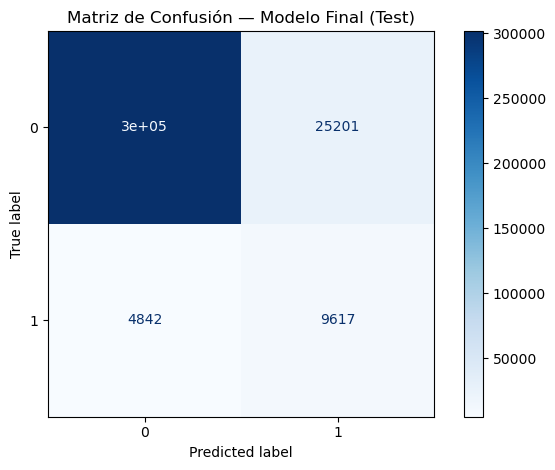

In [ ]:
cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title('Matriz de Confusión — Modelo Final (Test)')
plt.tight_layout()
plt.savefig('confusion_matrix_test.png', dpi=150)
plt.show()

PR-AUC (val): 0.5862


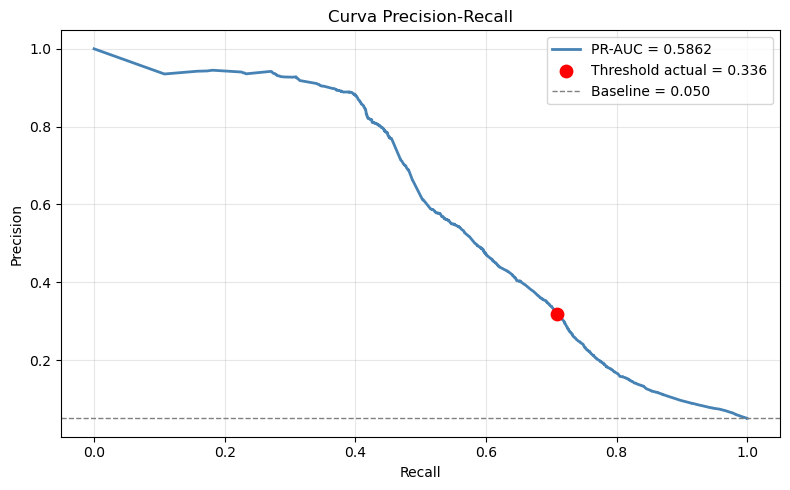

In [ ]:
from sklearn.metrics import average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt

# ── Calcular PR-AUC ──────────────────────────────────────────────────────────
y_prob_val = pipe_final.predict_proba(X_val)[:, 1]

pr_auc = average_precision_score(y_val, y_prob_val)
print(f'PR-AUC (val): {pr_auc:.4f}')

# ── Curva Precision-Recall ───────────────────────────────────────────────────
precision, recall, thresholds = precision_recall_curve(y_val, y_prob_val)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='steelblue', lw=2, label=f'PR-AUC = {pr_auc:.4f}')

# Marcar el threshold actual
threshold_idx = (abs(thresholds - THRESHOLD)).argmin()
plt.scatter(
    recall[threshold_idx],
    precision[threshold_idx],
    color='red', zorder=5, s=80,
    label=f'Threshold actual = {THRESHOLD:.3f}'
)

# Línea base (modelo aleatorio = ratio de positivos)
baseline = y_val.mean()
plt.axhline(y=baseline, color='gray', linestyle='--', lw=1, label=f'Baseline = {baseline:.3f}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.1 Escenarios operativos por threshold

La tabla siguiente permite elegir el threshold según la estrategia de campaña:

- **Bajo threshold (0.20–0.30)**: alto recall, muchos contactos → campaña masiva de bajo coste
- **Alto threshold (0.50–0.60)**: alta precisión, pocos contactos → campaña premium de alto coste

In [ ]:
from sklearn.metrics import precision_recall_curve

y_prob_test = pipe_final.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_test)

# Tabla de escenarios operativos
escenarios = []
for t in np.arange(0.20, 0.65, 0.05):
    y_pred = (y_prob_test >= t).astype(int)
    tp = ((y_pred == 1) & (y_test == 1)).sum()
    fp = ((y_pred == 1) & (y_test == 0)).sum()
    fn = ((y_pred == 0) & (y_test == 1)).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    escenarios.append({
        'threshold': t,
        'contactados': tp + fp,
        'compradores_detectados': tp,
        'precision': round(prec, 3),
        'recall': round(rec, 3),
        'f1': round(f1, 3)
    })

df_escenarios = pd.DataFrame(escenarios)
print(df_escenarios.to_string(index=False))

 threshold  contactados  compradores_detectados  precision  recall    f1
      0.20        88932                   11400      0.128   0.788 0.221
      0.25        62175                   10673      0.172   0.738 0.279
      0.30        44442                   10041      0.226   0.694 0.341
      0.35        31998                    9438      0.295   0.653 0.406
      0.40        22907                    8378      0.366   0.579 0.448
      0.45        17724                    7713      0.435   0.533 0.479
      0.50        16405                    7531      0.459   0.521 0.488
      0.55        13553                    7068      0.522   0.489 0.505
      0.60        12338                    6727      0.545   0.465 0.502


## 8. Feature Importance

=== TOP 15 FEATURES (Gain) ===
               Variable  Importance Score
       seniority_months          0.210201
      bought_last_month          0.166496
short_term_deposit_lag1          0.094135
          mortgage_lag1          0.069041
      em_account_p_lag1          0.056471
   cumulative_purchases          0.034114
         em_acount_lag2          0.031987
      pension_plan_lag1          0.026613
short_term_deposit_lag2          0.025733
           payroll_lag1          0.025516
          mes_particion          0.023541
         delta_products          0.022791
      entry_channel_KHE          0.016759
      entry_channel_KHQ          0.012191
  months_since_purchase          0.010668


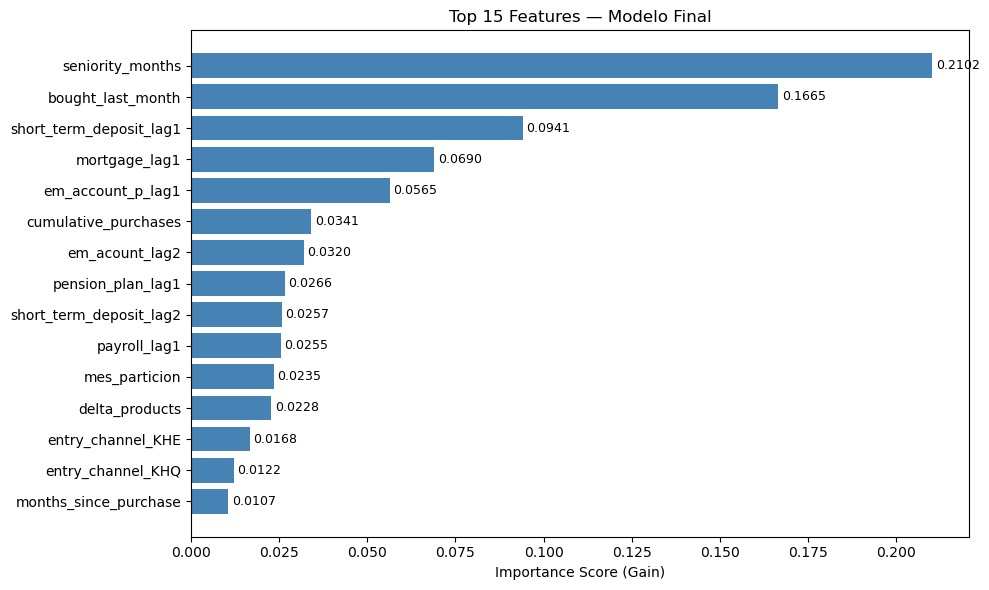

In [ ]:
nombres_columnas = pipe_final.named_steps['preprocessor'].get_feature_names_out()
importancias     = pipe_final.named_steps['modelo_xgb'].feature_importances_

df_imp = pd.DataFrame({
    'Variable':         [n.split('__')[-1] for n in nombres_columnas],
    'Importance Score': importancias
}).sort_values(by='Importance Score', ascending=False)

print('=== TOP 15 FEATURES (Gain) ===')
print(df_imp.head(15).to_string(index=False))

top15 = df_imp.head(15)
plt.figure(figsize=(10, 6))
bars = plt.barh(top15['Variable'][::-1], top15['Importance Score'][::-1], color='steelblue')
for bar, val in zip(bars, top15['Importance Score'][::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.xlabel('Importance Score (Gain)')
plt.title('Top 15 Features — Modelo Final')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

---
## 9. Análisis de Resultados



### 9.1 Productos más adquiridos en el Decil 1

Cruzamos los clientes del decil 1 con el catálogo de ventas real para identificar  
qué productos concentran las compras de los clientes más propensos.

Período analizado      : 2019-03-01
Clientes en decil 1    : 16,814
Compradores reales     : 5,915
Score medio            : 0.635
Score mínimo decil 1   : 0.373
Ventas registradas en decil 1 ese mes: 7,090

=== PRODUCTOS MÁS COMPRADOS — DECIL 1 ===
 product_ID      product_desc family_product n_ventas pct_ventas n_clientes margen_medio margen_total
       4657         em_acount        account    3,629      51.2%      3,629          $70     $252,824
       3819        debit_card   payment_card    1,354      19.1%      1,354          $60      $81,300
       2235   payroll_account        account      642       9.1%        642          $70      $45,062
       1364      pension_plan   pension_plan      484       6.8%        484       $5,991   $2,899,415
       2234           payroll        account      457       6.4%        457          $70      $31,784
       8871       emc_account        account      399       5.6%        399          $70      $28,014
       2312       credit_card   payme

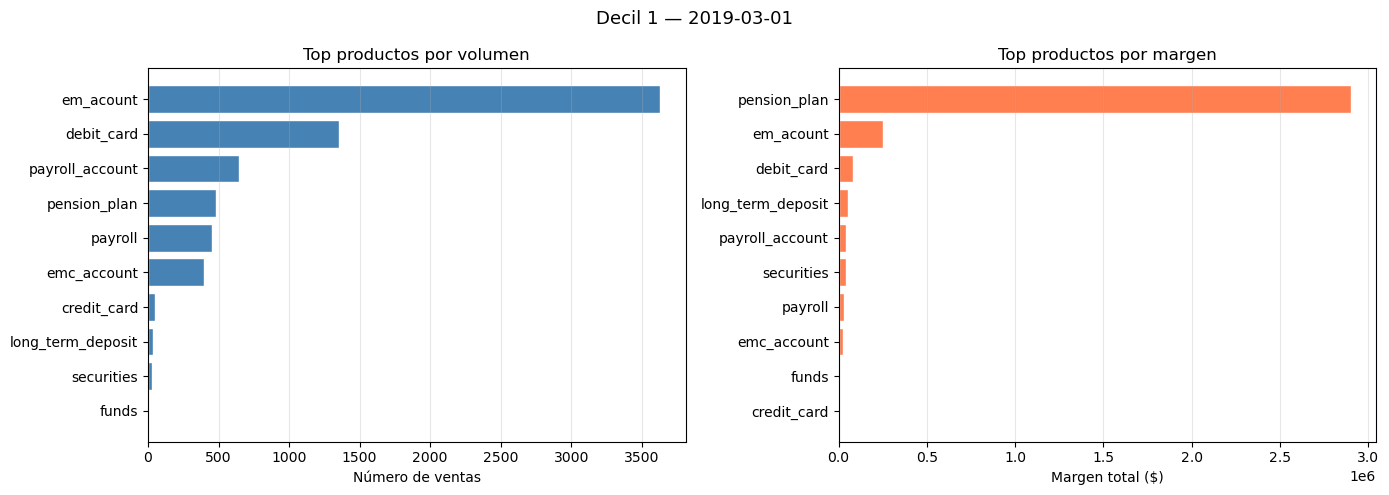


Dataframe de campaña listo: 16,814 clientes
    pk_cid  score_propension  compro_ese_mes  age  gender         salary  \
0  1536649          0.949465               1   41    Male  115436.986316   
1  1537218          0.949435               1   29  Female  109299.622357   
2  1536273          0.949435               1   42  Female  115948.433313   
3  1536272          0.949435               1   43  Female  116459.880309   
4  1536269          0.949435               1   45  Female  117482.774302   

             segment  n_products_total  
0  02 - PARTICULARES                 2  
1  02 - PARTICULARES                 1  
2  02 - PARTICULARES                 1  
3  02 - PARTICULARES                 1  
4  02 - PARTICULARES                 1  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Cargar ventas ─────────────────────────────────────────────────────────────
sales = pd.read_csv('/Users/guillermogonzalezcervantes/Downloads/datasets_TFM + diccionario/sales.csv', index_col=0)
sales['month_sale'] = pd.to_datetime(sales['month_sale'])

val_df = X_val.copy()
val_df['pk_cid']  = X_val.index
val_df['y_true']  = y_val.values
val_df['y_proba'] = y_prob_val

ultimo_mes = pd.to_datetime(val_df['pk_partition']).max()
val_ultimo = val_df[pd.to_datetime(val_df['pk_partition']) == ultimo_mes].copy()

# ── Asignar deciles ───────────────────────────────────────────────────────────
val_ultimo = val_ultimo.sort_values('y_proba', ascending=False).reset_index(drop=True)
val_ultimo['decil'] = pd.qcut(val_ultimo.index, q=10, labels=range(1, 11))

# ── Clientes del decil 1 ──────────────────────────────────────────────────────
decil1 = val_ultimo[val_ultimo['decil'] == 1].copy()

print(f'Período analizado      : {ultimo_mes.date()}')
print(f'Clientes en decil 1    : {len(decil1):,}')
print(f'Compradores reales     : {int(decil1["y_true"].sum()):,}')
print(f'Score medio            : {decil1["y_proba"].mean():.3f}')
print(f'Score mínimo decil 1   : {decil1["y_proba"].min():.3f}')

# ── Cruzar con ventas del mismo mes ──────────────────────────────────────────
sales = pd.read_csv('sales.csv', index_col=0)
sales['month_sale'] = pd.to_datetime(sales['month_sale'])

ventas_mes    = sales[sales['month_sale'] == ultimo_mes].copy()
ventas_decil1 = ventas_mes[ventas_mes['cid'].isin(decil1['pk_cid'])]

print(f'Ventas registradas en decil 1 ese mes: {len(ventas_decil1):,}')

# ── Cargar descripción de productos ──────────────────────────────────────────
product_desc = pd.read_csv('product_description.csv', index_col=0)

# ── Productos más comprados en decil 1 — enriquecido ─────────────────────────
productos_decil1 = (
    ventas_decil1
    .groupby('product_ID')
    .agg(
        n_ventas     = ('pk_sale',    'count'),
        margen_total = ('net_margin', 'sum'),
        margen_medio = ('net_margin', 'mean'),
        n_clientes   = ('cid',        'nunique'),
    )
    .sort_values('n_ventas', ascending=False)
    .reset_index()
)
productos_decil1['pct_ventas'] = (
    productos_decil1['n_ventas'] / productos_decil1['n_ventas'].sum() * 100
)

# Merge con descripción
productos_decil1 = productos_decil1.merge(
    product_desc[['pk_product_ID', 'product_desc', 'family_product']],
    left_on='product_ID', right_on='pk_product_ID', how='left'
).drop(columns='pk_product_ID')

# Reordenar columnas
productos_decil1 = productos_decil1[[
    'product_ID', 'product_desc', 'family_product',
    'n_ventas', 'pct_ventas', 'n_clientes',
    'margen_medio', 'margen_total'
]]

print('\n=== PRODUCTOS MÁS COMPRADOS — DECIL 1 ===')
print(productos_decil1.to_string(
    index=False,
    formatters={
        'n_ventas':     '{:,}'.format,
        'margen_total': '${:,.0f}'.format,
        'margen_medio': '${:,.0f}'.format,
        'n_clientes':   '{:,}'.format,
        'pct_ventas':   '{:.1f}%'.format,
    }
))

# ── Resumen por familia de producto ──────────────────────────────────────────
familia = (
    productos_decil1
    .groupby('family_product')
    .agg(
        n_ventas     = ('n_ventas',     'sum'),
        margen_total = ('margen_total', 'sum'),
        n_productos  = ('product_desc', 'count'),
    )
    .sort_values('n_ventas', ascending=False)
    .reset_index()
)
familia['pct_ventas'] = familia['n_ventas'] / familia['n_ventas'].sum() * 100

print('\n=== RESUMEN POR FAMILIA ===')
print(familia.to_string(
    index=False,
    formatters={
        'n_ventas':     '{:,}'.format,
        'margen_total': '${:,.0f}'.format,
        'pct_ventas':   '{:.1f}%'.format,
    }
))

# ── Gráficos ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Decil 1 — {ultimo_mes.date()}', fontsize=13)

# Por volumen con nombre de producto
top_vol = productos_decil1.head(10)
axes[0].barh(top_vol['product_desc'], top_vol['n_ventas'],
             color='steelblue', edgecolor='white')
axes[0].set_xlabel('Número de ventas')
axes[0].set_title('Top productos por volumen')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Por margen total con nombre de producto
top_margen = productos_decil1.sort_values('margen_total', ascending=False).head(10)
axes[1].barh(top_margen['product_desc'], top_margen['margen_total'],
             color='coral', edgecolor='white')
axes[1].set_xlabel('Margen total ($)')
axes[1].set_title('Top productos por margen')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# ── Exportar lista de clientes decil 1 para campaña ──────────────────────────
campaña = decil1[['pk_cid', 'y_proba', 'y_true',
                   'age', 'gender', 'salary', 'segment', 'n_products_total']].copy()
campaña = campaña.rename(columns={
    'y_proba': 'score_propension',
    'y_true':  'compro_ese_mes'
})
campaña = campaña.sort_values('score_propension', ascending=False).reset_index(drop=True)

print(f'\nDataframe de campaña listo: {len(campaña):,} clientes')
print(campaña.head())

### 9.3 Perfil del comprador real (Test)

Analizamos los clientes que el modelo predijo como compradores y efectivamente compraron.

In [ ]:
X_test_analisis = X_test.copy()
X_test_analisis['y_real'] = y_test.values
X_test_analisis['y_pred'] = y_pred_test

compradores    = X_test_analisis[(X_test_analisis['y_real'] == 1) &
                                  (X_test_analisis['y_pred'] == 1)]
no_compradores = X_test_analisis[X_test_analisis['y_real'] == 0]

print('=== PERFIL COMPRADORES vs NO COMPRADORES ===\n')
for col in ['age', 'salary', 'seniority_months', 'n_products_total']:
    print(f'{col}:')
    print(f'  Compradores:    {compradores[col].mean():.1f}')
    print(f'  No compradores: {no_compradores[col].mean():.1f}')
    print()

print('=== SEGMENTO ===')
print(compradores['segment'].value_counts(normalize=True).mul(100).round(1).to_string())

print('\n=== CANAL DE ENTRADA (Top 5) ===')
print(compradores['entry_channel'].value_counts(normalize=True)
      .head(5).mul(100).round(1).to_string())

=== PERFIL COMPRADORES vs NO COMPRADORES ===

age:
  Compradores:    39.4
  No compradores: 33.9

salary:
  Compradores:    119733.6
  No compradores: 116527.9

seniority_months:
  Compradores:    3.8
  No compradores: 22.6

n_products_total:
  Compradores:    1.8
  No compradores: 1.6

=== SEGMENTO ===
segment
02 - PARTICULARES     66.2
00 - NO SEGMENTADO    14.0
03 - UNIVERSITARIO    13.1
01 - TOP               6.6

=== CANAL DE ENTRADA (Top 5) ===
entry_channel
KHM        47.5
KHN        23.8
UNKNOWN    13.8
KHE         3.1
KHO         2.6


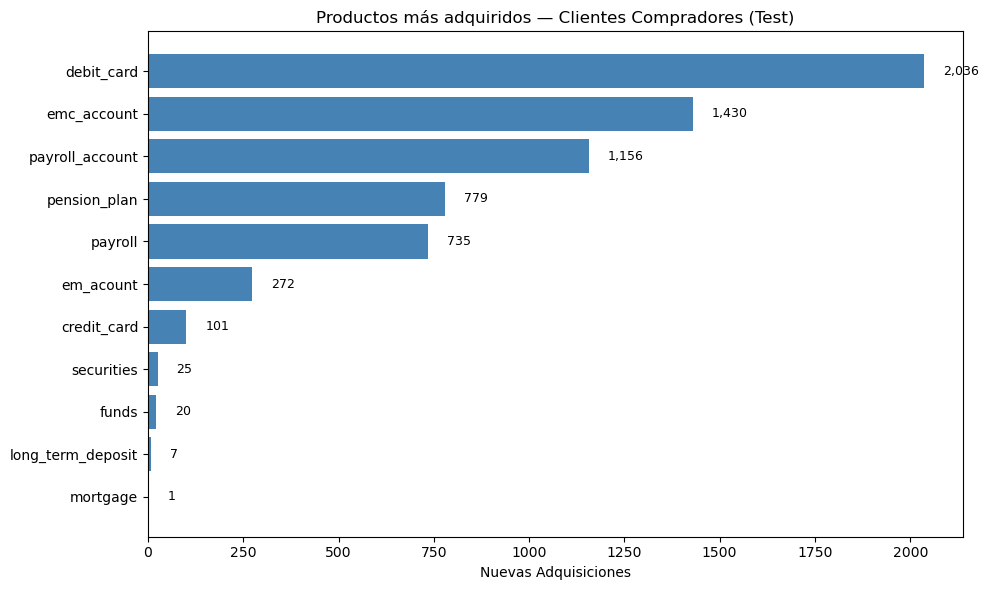

In [ ]:
df_test_copy = df_test.copy()
df_test_copy['y_pred'] = y_pred_test
compradores_test = df_test_copy[df_test_copy['y_pred'] == 1]

nuevos_productos = {}
for col in PRODUCT_COLS:
    if f'{col}_lag1' in compradores_test.columns:
        nuevos = ((compradores_test[col] == 1) &
                  (compradores_test[f'{col}_lag1'] == 0)).sum()
        nuevos_productos[col] = nuevos

productos_df = (pd.DataFrame.from_dict(nuevos_productos, orient='index',
                                        columns=['nuevas_adquisiciones'])
                  .sort_values('nuevas_adquisiciones', ascending=False))

productos_plot = productos_df[productos_df['nuevas_adquisiciones'] > 0].sort_values(
    'nuevas_adquisiciones', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(productos_plot.index, productos_plot['nuevas_adquisiciones'], color='steelblue')
for bar, val in zip(bars, productos_plot['nuevas_adquisiciones']):
    plt.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)
plt.xlabel('Nuevas Adquisiciones')
plt.title('Productos más adquiridos — Clientes Compradores (Test)')
plt.tight_layout()
plt.savefig('productos_mas_vendidos.png', dpi=150)
plt.show()

---
## 10. Conclusiones

### 10.1 Rendimiento del modelo

| Métrica | Validación | Test | Interpretación |
|---------|-----------|------|----------------|
| **Precision** (clase 1) | 0.32 | 0.28 | 28-32 de cada 100 contactados compran |
| **Recall** (clase 1) | 0.71 | 0.67 | El modelo detecta 2 de cada 3 compradores |
| **F1-score** | 0.44 | 0.39 | Balance precision-recall |
| **PR-AUC** | 0.586 | — | Por encima del baseline aleatorio (0.050) |
| **Accuracy** | 0.91 | 0.91 | Estable entre val y test |

> La pequeña diferencia val→test (~5pp en F1) confirma que el modelo **generaliza bien** y no sufre overfitting severo.

---

### 10.2 Capacidad de targeting — Lift por deciles

| Decil | Clientes (10%) | Compradores capturados | Lift | % Captura acumulada |
|-------|---------------|------------------------|------|---------------------|
| 1 (top) | 16,814 | 5,915 | **6.97x** | 69.7% |
| 1-2 | 33,628 | 6,605 | 3.89x | 77.8% |
| 1-3 | 50,441 | 7,015 | 2.75x | 82.6% |

**Conclusión operativa:** Contactando solo el **10% de clientes** (los de mayor score),  
el modelo captura el **70% de todos los compradores** — 7 veces más eficiente que un envío masivo.

---

### 10.3 Hallazgos sobre el perfil del comprador

| Variable | Comprador | No comprador | Δ | Insight |
|---------|-----------|-------------|---|---------|
| Edad media | 39.4 | 33.9 | +16% | Clientes más maduros compran más |
| **Antigüedad (meses)** | **3.8** | **22.6** | **-83%** | Los clientes nuevos son los que más compran |
| Productos totales | 1.8 | 1.6 | +12% | Ligeramente más productos previos |
| Salario | 119,734€ | 116,528€ | +3% | Diferencia no significativa |

**El hallazgo clave:** La antigüedad baja (-83%) es el predictor más diferenciador.  
Los clientes recién captados están en fase de adopción y son los que más productos adquieren.

---

### 10.4 Features más importantes del modelo

| Rank | Feature | Importancia | Tipo |
|------|---------|-------------|------|
| 1 | `seniority_months` | 0.210 | Antigüedad del cliente |
| 2 | `bought_last_month` | 0.166 | Compró el mes pasado |
| 3 | `short_term_deposit_lag1` | 0.094 | Tenía depósito corto plazo |
| 4 | `mortgage_lag1` | 0.069 | Tenía hipoteca |
| 5 | `em_account_p_lag1` | 0.056 | Tenía cuenta especial |

Las **lag features** (historial de productos) dominan el top 15, confirmando la hipótesis del EDA:  
el comportamiento pasado del cliente es la señal más predictiva de compra futura.

---

### 10.5 Producto más comprado en el segmento de alta propensión

| Producto | Familia | Ventas (Decil 1) | Margen total |
|---------|---------|-----------------|-------------|
| em_acount | account | 3,629 (51.2%) | $252,824 |
| debit_card | payment_card | 1,354 (19.1%) | $81,300 |
| payroll_account | account | 642 (9.1%) | $45,062 |
| **pension_plan** | **pension_plan** | **484 (6.8%)** | **$2,899,415** |

> El **plan de pensiones** es poco frecuente (6.8%) pero genera el **86% del margen total** del decil 1.
> Estrategia recomendada: priorizar cross-sell de pension_plan en clientes del decil 1 con edad > 35.

---

### 10.6 Limitaciones y próximos pasos

**Limitaciones:**
- **Precisión baja (~28%)**: 72% de contactos no convierten. Aceptable para campañas de bajo coste;  
  para campañas premium conviene usar threshold > 0.50.
- **Sin datos de comportamiento digital**: email, web, app. Incorporarlos aumentaría la precisión significativamente.
- **Target binario**: el modelo predice *si compra*, no *qué producto*. Se podría entrenar un modelo por producto.


